## Fake Job Posting Detection - Model Training

This notebook focuses on training an LSTM-based Recurrent Neural Network (RNN) model for detecting fraudulent job postings. The key steps include:

- **Data Preprocessing:** Tokenizing text data and handling class imbalance using SMOTE.
- **Model Training:** Implementing an LSTM-RNN architecture to capture sequential dependencies.
- **Evaluation:** Assessing model performance using appropriate metrics.

Let's proceed with building an effective fraud detection model!

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns

### Load the dataset

In [2]:
df = pd.read_csv("fake_job_postings.csv")

In [3]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


### Some Data Preprocessing and Feature Engineering 

In [4]:
df.shape

(18370, 18)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18370 entries, 0 to 18369
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   job_id               18370 non-null  int64 
 1   title                18370 non-null  object
 2   location             18024 non-null  object
 3   department           6823 non-null   object
 4   salary_range         3358 non-null   object
 5   company_profile      15059 non-null  object
 6   description          18369 non-null  object
 7   requirements         15674 non-null  object
 8   benefits             11158 non-null  object
 9   telecommuting        18370 non-null  int64 
 10  has_company_logo     18370 non-null  int64 
 11  has_questions        18370 non-null  int64 
 12  employment_type      14899 non-null  object
 13  required_experience  11320 non-null  object
 14  required_education   10265 non-null  object
 15  industry             13467 non-null  object
 16  func

In [6]:
df.nunique()

job_id                 18370
title                  11254
location                3411
department              1343
salary_range            1190
company_profile         2020
description            15043
requirements           11985
benefits                6222
telecommuting              2
has_company_logo           2
has_questions              2
employment_type            6
required_experience        8
required_education        13
industry                 140
function                  42
fraudulent                 2
dtype: int64

In [7]:
df['fraudulent'].value_counts()

fraudulent
0    17256
1     1114
Name: count, dtype: int64

In [8]:
df.isnull().sum()

job_id                     0
title                      0
location                 346
department             11547
salary_range           15012
company_profile         3311
description                1
requirements            2696
benefits                7212
telecommuting              0
has_company_logo           0
has_questions              0
employment_type         3471
required_experience     7050
required_education      8105
industry                4903
function                6455
fraudulent                 0
dtype: int64

In [9]:
df['location'].fillna('Unknown', inplace=True)
df['department'].fillna('Unknown', inplace=True)
df['salary_range'].fillna('Not Specified', inplace=True)
df['employment_type'].fillna('Not Specified', inplace=True)
df['required_experience'].fillna('Not Specified', inplace=True)
df['required_education'].fillna('Not Specified', inplace=True)
df['industry'].fillna('Not Specified', inplace=True)
df['function'].fillna('Not Specified', inplace=True)

C:\Users\abhi8\AppData\Local\Temp\ipykernel_13256\1166088697.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['location'].fillna('Unknown', inplace=True)
C:\Users\abhi8\AppData\Local\Temp\ipykernel_13256\1166088697.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [10]:
df.head()

,job_id,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent
0,1,Marketing Intern,"US, NY, New York",Marketing,Not Specified,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,Not Specified,Not Specified,Marketing,0
1,2,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,Not Specified,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,Not Specified,Marketing and Advertising,Customer Service,0
2,3,Commissioning Machinery Assistant (CMA),"US, IA, Wever",Unknown,Not Specified,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,Not Specified,Not Specified,Not Specified,Not Specified,Not Specified,0
3,4,Account Executive - Washington DC,"US, DC, Washington",Sales,Not Specified,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0
4,5,Bill Review Manager,"US, FL, Fort Worth",Unknown,Not Specified,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0


### Combining the Categorical/text features

In [11]:
df['combined_text'] = df[['title', 'location', 'salary_range', 'company_profile', 'description', 
                          'requirements', 'benefits', 'employment_type', 
                          'required_experience', 'required_education', 'industry', 
                          'function', 'department']].apply(
    lambda x: ' '.join(x.fillna('').astype(str)), axis=1
)

In [12]:
df.isnull().sum()

job_id                    0
title                     0
location                  0
department                0
salary_range              0
company_profile        3311
description               1
requirements           2696
benefits               7212
telecommuting             0
has_company_logo          0
has_questions             0
employment_type           0
required_experience       0
required_education        0
industry                  0
function                  0
fraudulent                0
combined_text             0
dtype: int64

In [13]:
text_columns = ['title', 'company_profile', 'description', 'requirements', 'benefits']
df[text_columns] = df[text_columns].fillna('Missing')

In [14]:
df.isna().sum()

job_id                 0
title                  0
location               0
department             0
salary_range           0
company_profile        0
description            0
requirements           0
benefits               0
telecommuting          0
has_company_logo       0
has_questions          0
employment_type        0
required_experience    0
required_education     0
industry               0
function               0
fraudulent             0
combined_text          0
dtype: int64

### Dropping the individual features

In [15]:
df.drop(columns=['title',
                 'location',
                 'salary_range',
                 'company_profile',
                 'description',
                 'requirements',
                 'benefits',
                 'employment_type',
                 'required_experience',
                 'required_education',
                 'industry',
                 'function',
                 'department',
                 'job_id',
                 'has_questions',
                 'telecommuting'], inplace=True)

In [16]:
df.head()

,has_company_logo,fraudulent,combined_text
0,1,0,"Marketing Intern US, NY, New York Not Specifie..."
1,1,0,"Customer Service - Cloud Video Production NZ, ..."
2,1,0,"Commissioning Machinery Assistant (CMA) US, IA..."
3,1,0,"Account Executive - Washington DC US, DC, Wash..."
4,1,0,"Bill Review Manager US, FL, Fort Worth Not Spe..."


### Text Preprocessing - Cleaning Job Descriptions

In [17]:
def clean_text(text):
    text = re.sub(r'http\S+|www\S+', '', text)  
    text = re.sub(r'[^a-zA-Z\s]', '', text)  
    text = text.lower().strip()  
    return text

### Applying it to "combined_text" feature

In [18]:
# Apply text cleaning
df['combined_text'] = df['combined_text'].apply(clean_text)

### Using LabelEncoder() for target feature

In [19]:
le = LabelEncoder()
df['fraudulent'] = le.fit_transform(df['fraudulent'])

In [20]:
df.head()

,has_company_logo,fraudulent,combined_text
0,1,0,marketing intern us ny new york not specified ...
1,1,0,customer service cloud video production nz a...
2,1,0,commissioning machinery assistant cma us ia we...
3,1,0,account executive washington dc us dc washing...
4,1,0,bill review manager us fl fort worth not speci...


### Tokenization and Sequence Conversion

To prepare text data for the LSTM model, we:
- Limit the vocabulary size to 10,000 words.
- Convert text into sequences of word indices.
- Standardize sequence lengths to ensure uniform input shape.

In [21]:
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 100
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df['combined_text'])
sequences = tokenizer.texts_to_sequences(df['combined_text'])

### Padding Sequences and Defining Target Variable

- **Padding:** Ensures all sequences have a uniform length of 200.
- **Target Variable:** The `fraudulent` column is extracted as the target label for classification.

This step prepares the data for model training.


In [22]:
X = pad_sequences(sequences, maxlen=MAX_SEQUENCE_LENGTH)

y = df['fraudulent']

### Handling Imbalanced Data with SMOTE

- **SMOTE (Synthetic Minority Over-sampling Technique):** Used to balance the dataset by generating synthetic samples for the minority class.
- **Resampling:** Ensures a more balanced distribution of fraudulent and non-fraudulent job postings.

In [23]:
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)


In [24]:
print("Original Dataset Shape:", X.shape, y.shape)
print("After SMOTE Resampling Shape:", X_resampled.shape, y_resampled.shape)

Original Dataset Shape: (18370, 200) (18370,)
After SMOTE Resampling Shape: (34512, 200) (34512,)


### Splitting the dataset into train and test

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42)

### Building the LSTM Model

In [26]:
print("Training LSTM Model...")
lstm_model = Sequential([
    Embedding(MAX_VOCAB_SIZE, EMBEDDING_DIM),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

Training LSTM Model...


### Compiling and Training the LSTM Model

In [27]:
lstm_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
# Step 1: Define the rules
early_stop = EarlyStopping(
    monitor='val_loss',         # Watch the validation loss
    patience=5,                 # Wait 5 epochs before stopping
    restore_best_weights=True,  # IMPORTANT: Go back to the best epoch
    verbose=1
)
# Step 2: Plug it into training
lstm_history = lstm_model.fit(
    X_train, y_train, 
    epochs=5, 
    batch_size=32, 
    validation_data=(X_test, y_test), 
    callbacks=[early_stop]
)

Epoch 1/5
863/863 ━━━━━━━━━━━━━━━━━━━━ 227s 252ms/step - accuracy: 0.9128 - loss: 0.2453 - val_accuracy: 0.9732 - val_loss: 0.0867
Epoch 2/5
863/863 ━━━━━━━━━━━━━━━━━━━━ 167s 193ms/step - accuracy: 0.9787 - loss: 0.0737 - val_accuracy: 0.9765 - val_loss: 0.0720
Epoch 3/5
863/863 ━━━━━━━━━━━━━━━━━━━━ 142s 165ms/step - accuracy: 0.9838 - loss: 0.0543 - val_accuracy: 0.9825 - val_loss: 0.0592
Epoch 4/5
863/863 ━━━━━━━━━━━━━━━━━━━━ 215s 180ms/step - accuracy: 0.9870 - loss: 0.0435 - val_accuracy: 0.9812 - val_loss: 0.0667
Epoch 5/5
863/863 ━━━━━━━━━━━━━━━━━━━━ 283s 328ms/step - accuracy: 0.9905 - loss: 0.0304 - val_accuracy: 0.9815 - val_loss: 0.0776
Restoring model weights from the end of the best epoch: 3.


### LSTM Model Accuracy Plot

- The graph shows training and validation accuracy trends over epochs.

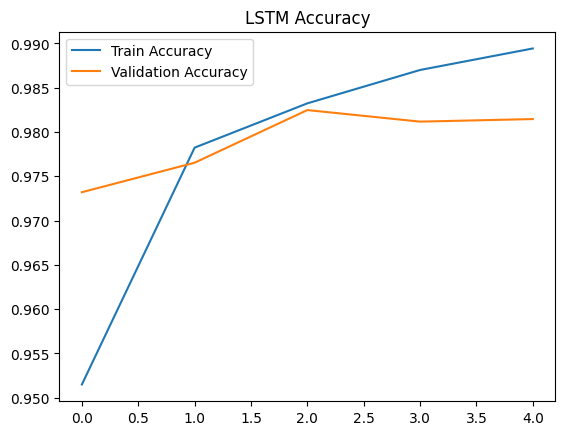

In [28]:
plt.plot(lstm_history.history['accuracy'], label='Train Accuracy')
plt.plot(lstm_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Accuracy')
plt.legend()
plt.show()

### LSTM Model Evaluation 

216/216 ━━━━━━━━━━━━━━━━━━━━ 22s 94ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      3472
           1       0.99      0.98      0.98      3431

    accuracy                           0.98      6903
   macro avg       0.98      0.98      0.98      6903
weighted avg       0.98      0.98      0.98      6903

LSTM F1 Score: 0.9822970007315289


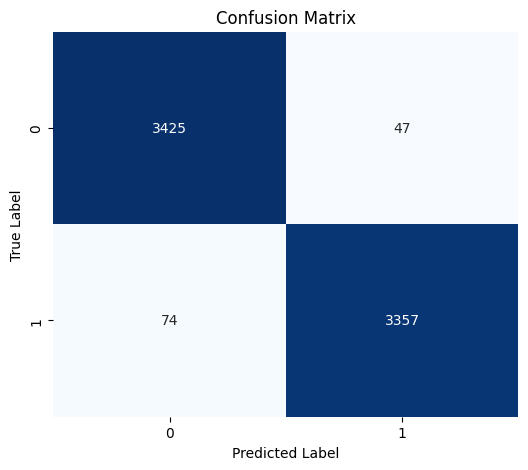

In [29]:
# 1. Make predictions on the test set
y_pred_probs = lstm_model.predict(X_test)

# 2. Convert probabilities to binary classes (0 or 1)
# Threshold is set to 0.5
y_pred = (y_pred_probs > 0.5).astype("int32")

# 3. Print the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("LSTM F1 Score:", f1_score(y_test, y_pred))

# 4. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### Saving the LSTM Model

In [30]:
lstm_model.save("fake_job_lstm_model.keras")

### Saving the Tokenizer

In [32]:
import pickle
with open("tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
